## INDENG 210 Final Project: Group 1

In [1]:
import numpy as np
import pandas as pd
import sklearn
import matplotlib.pyplot as plt

In [2]:
# PARKING_URL = (
#     "https://safitwebapps.blob.core.windows.net/$web/streets/sfpark/"
#     "SFpark_ParkingSensorData_HourlyOccupancy_20112013.csv"
# )
# EVENTS_URL = "https://www.sfmta.com/media/12019/download?inline="
# WEATHER_URL = "https://www.sfmta.com/media/12021/download?inline="

In [3]:
# parking = pd.read_csv(PARKING_URL, nrows=500_000)
# events = pd.read_csv(EVENTS_URL)
# weather = pd.read_csv(WEATHER_URL)

In [4]:
parking = pd.read_csv('parking.csv')
events = pd.read_csv('events.csv')
weather = pd.read_csv('weather.csv')

In [5]:
print(parking.shape)
print(events.shape)
print(weather.shape)

(500000, 33)
(386, 10)
(2725, 5)


In [6]:
parking.head()

,BLOCK_ID,STREET_NAME,BLOCK_NUM,STREET_BLOCK,AREA_TYPE,PM_DISTRICT_NAME,RATE,START_TIME_DT,TOTAL_TIME,TOTAL_OCCUPIED_TIME,...,GMP_UNKNOWN_TIME,COMM_TIME,COMM_OCCUPIED_TIME,COMM_VACANT_TIME,COMM_UNKNOWN_TIME,CAL_MONTH_NAME,CAL_YEAR,CAL_DATE,DAY_TYPE,TIME_OF_DAY
0,41522,FILLMORE ST,22,FILLMORE ST 2200,Pilot,Fillmore,NaN,01-jul-2012 21:00:00,61200,35847,...,0,0,0,0,0,July,2012,01-jul-2012,weekend,2100
1,41524,FILLMORE ST,24,FILLMORE ST 2400,Pilot,Fillmore,NaN,01-jul-2012 22:00:00,64800,27576,...,0,0,0,0,0,July,2012,01-jul-2012,weekend,2200
2,50001,JACKSON ST,1,JACKSON ST 100,Pilot,Downtown,NaN,01-jul-2012 02:00:00,79200,39985,...,0,0,0,0,0,July,2012,01-jul-2012,weekend,200
3,50002,JACKSON ST,2,JACKSON ST 200,Pilot,Downtown,NaN,01-jul-2012 08:00:00,82800,30465,...,0,0,0,0,0,July,2012,01-jul-2012,weekend,800
4,10903,09TH AVE,3,09TH AVE 300,Control,Inner Richmond,NaN,01-jul-2012 08:00:00,93600,85690,...,0,0,0,0,0,July,2012,01-jul-2012,weekend,800


In [7]:
parking.columns

Index(['BLOCK_ID', 'STREET_NAME', 'BLOCK_NUM', 'STREET_BLOCK', 'AREA_TYPE',
       'PM_DISTRICT_NAME', 'RATE', 'START_TIME_DT', 'TOTAL_TIME',
       'TOTAL_OCCUPIED_TIME', 'TOTAL_VACANT_TIME', 'TOTAL_UNKNOWN_TIME',
       'OP_TIME', 'OP_OCCUPIED_TIME', 'OP_VACANT_TIME', 'OP_UNKNOWN_TIME',
       'NONOP_TIME', 'NONOP_OCCUPIED_TIME', 'NONOP_VACANT_TIME',
       'NONOP_UNKNOWN_TIME', 'GMP_TIME', 'GMP_OCCUPIED_TIME',
       'GMP_VACANT_TIME', 'GMP_UNKNOWN_TIME', 'COMM_TIME',
       'COMM_OCCUPIED_TIME', 'COMM_VACANT_TIME', 'COMM_UNKNOWN_TIME',
       'CAL_MONTH_NAME', 'CAL_YEAR', 'CAL_DATE', 'DAY_TYPE', 'TIME_OF_DAY'],
      dtype='object')

In [8]:
parking.dtypes.to_string()

'BLOCK_ID                 int64\nSTREET_NAME             object\nBLOCK_NUM                int64\nSTREET_BLOCK            object\nAREA_TYPE               object\nPM_DISTRICT_NAME        object\nRATE                   float64\nSTART_TIME_DT           object\nTOTAL_TIME               int64\nTOTAL_OCCUPIED_TIME      int64\nTOTAL_VACANT_TIME        int64\nTOTAL_UNKNOWN_TIME       int64\nOP_TIME                  int64\nOP_OCCUPIED_TIME         int64\nOP_VACANT_TIME           int64\nOP_UNKNOWN_TIME          int64\nNONOP_TIME               int64\nNONOP_OCCUPIED_TIME      int64\nNONOP_VACANT_TIME        int64\nNONOP_UNKNOWN_TIME       int64\nGMP_TIME                 int64\nGMP_OCCUPIED_TIME        int64\nGMP_VACANT_TIME          int64\nGMP_UNKNOWN_TIME         int64\nCOMM_TIME                int64\nCOMM_OCCUPIED_TIME       int64\nCOMM_VACANT_TIME         int64\nCOMM_UNKNOWN_TIME        int64\nCAL_MONTH_NAME          object\nCAL_YEAR                 int64\nCAL_DATE                object\nDAY_TYP

In [9]:
parking['PM_DISTRICT_NAME'].unique()

array(['Fillmore', 'Downtown', 'Inner Richmond', 'West Portal',
       'South Embarcadero', 'Marina', "Fisherman's Wharf", 'Civic Center',
       'Mission', 'Union'], dtype=object)

In [10]:
parking[parking['PM_DISTRICT_NAME'] == 'West Portal'].shape[0]

11704

In [11]:
mask = (parking['PM_DISTRICT_NAME'] != 'West Portal')
parking = parking[mask]
parking.shape


(488296, 33)

In [12]:
parking['BLOCK_ID'].nunique()

401

In [13]:
parking['CAL_DATE'] = pd.to_datetime(
    parking['CAL_DATE'],
    format='%d-%b-%Y'
)

print(parking['CAL_DATE'].min())
print(parking['CAL_DATE'].max())

2011-04-01 00:00:00
2013-07-29 00:00:00


### Parking Supply

In [14]:
supply = parking.copy()
supply.head(3)

,BLOCK_ID,STREET_NAME,BLOCK_NUM,STREET_BLOCK,AREA_TYPE,PM_DISTRICT_NAME,RATE,START_TIME_DT,TOTAL_TIME,TOTAL_OCCUPIED_TIME,...,GMP_UNKNOWN_TIME,COMM_TIME,COMM_OCCUPIED_TIME,COMM_VACANT_TIME,COMM_UNKNOWN_TIME,CAL_MONTH_NAME,CAL_YEAR,CAL_DATE,DAY_TYPE,TIME_OF_DAY
0,41522,FILLMORE ST,22,FILLMORE ST 2200,Pilot,Fillmore,NaN,01-jul-2012 21:00:00,61200,35847,...,0,0,0,0,0,July,2012,2012-07-01,weekend,2100
1,41524,FILLMORE ST,24,FILLMORE ST 2400,Pilot,Fillmore,NaN,01-jul-2012 22:00:00,64800,27576,...,0,0,0,0,0,July,2012,2012-07-01,weekend,2200
2,50001,JACKSON ST,1,JACKSON ST 100,Pilot,Downtown,NaN,01-jul-2012 02:00:00,79200,39985,...,0,0,0,0,0,July,2012,2012-07-01,weekend,200


In [15]:

supply['NUM_SPACES'] = parking['TOTAL_TIME'] / 3600

In [16]:
supply['NUM_SPACES']

0         17.0
1         18.0
2         22.0
3         23.0
4         26.0
          ... 
499995    59.0
499996    42.0
499997    39.0
499998     1.0
499999    10.0
Name: NUM_SPACES, Length: 488296, dtype: float64

In [17]:
supply.groupby('BLOCK_ID')['NUM_SPACES'].unique()

BLOCK_ID
902            [36.0, 47.0, 44.0, 46.0]
10202                             [1.0]
10203             [6.0, 10.0, 9.0, 8.0]
10302                   [6.0, 5.0, 7.0]
10303         [2.0, 8.0, 7.0, 9.0, 6.0]
                      ...              
84703                      [21.0, 22.0]
84704                       [12.0, 1.0]
84705                   [6.0, 9.0, 8.0]
86404    [27.0, 35.0, 36.0, 21.0, 18.0]
86502                   [3.0, 8.0, 7.0]
Name: NUM_SPACES, Length: 401, dtype: object

In [18]:
supply.groupby('BLOCK_ID')['NUM_SPACES'].agg(['min', 'max', 'median'])

,min,max,median
BLOCK_ID,,,
902,36.0,47.0,47.0
10202,1.0,1.0,1.0
10203,6.0,10.0,9.0
10302,5.0,7.0,6.0
10303,2.0,9.0,8.0
...,...,...,...
84703,21.0,22.0,21.0
84704,1.0,12.0,12.0
84705,6.0,9.0,9.0


In [19]:
space_summary = supply.groupby('BLOCK_ID')['NUM_SPACES'].agg(
    min_spaces='min',
    max_spaces='max',
    median_spaces='median',
    mode_spaces=lambda x: x.mode().iloc[0],
    num_unique='nunique'
)

space_summary.head()

,min_spaces,max_spaces,median_spaces,mode_spaces,num_unique
BLOCK_ID,,,,,
902,36.0,47.0,47.0,47.0,4
10202,1.0,1.0,1.0,1.0,1
10203,6.0,10.0,9.0,9.0,4
10302,5.0,7.0,6.0,6.0,3
10303,2.0,9.0,8.0,8.0,5


In [20]:
space_summary['range'] = (
    space_summary['max_spaces']
    - space_summary['min_spaces']
)

In [21]:
(space_summary['num_unique'] == 1).sum()

np.int64(87)

In [22]:
(space_summary['num_unique'] != 1).sum()

np.int64(314)

In [23]:
space_summary.sort_values('range', ascending=False).head()

,min_spaces,max_spaces,median_spaces,mode_spaces,num_unique,range
BLOCK_ID,,,,,,
56820,6.0,39.0,7.0,7.0,3,33.0
65800,1.0,31.0,31.0,31.0,6,30.0
22035,11.0,34.0,27.0,27.0,10,23.0
41806,34.0,57.0,43.0,37.0,9,23.0
46300,6.0,28.0,7.0,7.0,5,22.0


In [24]:
block_info = parking[
    ['BLOCK_ID', 'STREET_NAME', 'STREET_BLOCK',
     'PM_DISTRICT_NAME', 'AREA_TYPE']
].drop_duplicates()
print(block_info.shape)
print(block_info['BLOCK_ID'].nunique())

(401, 5)
401


In [25]:
space_summary.reset_index()
space_summary.head(3)

,min_spaces,max_spaces,median_spaces,mode_spaces,num_unique,range
BLOCK_ID,,,,,,
902,36.0,47.0,47.0,47.0,4,11.0
10202,1.0,1.0,1.0,1.0,1,0.0
10203,6.0,10.0,9.0,9.0,4,4.0


In [26]:
ss = space_summary.merge(block_info, left_on='BLOCK_ID', right_on='BLOCK_ID')
ss.head()

,BLOCK_ID,min_spaces,max_spaces,median_spaces,mode_spaces,num_unique,range,STREET_NAME,STREET_BLOCK,PM_DISTRICT_NAME,AREA_TYPE
0,902,36.0,47.0,47.0,47.0,4,11.0,CALIFORNIA ST,California and Steiner Lot,Fillmore,Pilot
1,10202,1.0,1.0,1.0,1.0,1,0.0,02ND AVE,02ND AVE 200,Inner Richmond,Control
2,10203,6.0,10.0,9.0,9.0,4,4.0,02ND AVE,02ND AVE 300,Inner Richmond,Control
3,10302,5.0,7.0,6.0,6.0,3,2.0,03RD AVE,03RD AVE 200,Inner Richmond,Control
4,10303,2.0,9.0,8.0,8.0,5,7.0,03RD AVE,03RD AVE 300,Inner Richmond,Control


In [27]:
ss['mode_spaces'].describe()

count    401.000000
mean      18.810474
std       11.290438
min        1.000000
25%       10.000000
50%       17.000000
75%       26.000000
max       65.000000
Name: mode_spaces, dtype: float64

In [28]:
ss['range'].describe()

count    401.000000
mean       3.907731
std        4.618871
min        0.000000
25%        1.000000
50%        2.000000
75%        6.000000
max       33.000000
Name: range, dtype: float64

In [29]:
spaces_block = ss.groupby('STREET_BLOCK')[['mode_spaces']].mean()
spaces_block.sort_values('mode_spaces', ascending=False).head()


,mode_spaces
STREET_BLOCK,
GROVE ST 0,65.0
BRANNAN ST 100,59.0
BRANNAN ST 500,57.0
BRYANT ST 400,55.0
BRANNAN ST 300,54.0


In [30]:
spaces_block.sort_values('mode_spaces', ascending=True)

,mode_spaces
STREET_BLOCK,
02ND AVE 200,1.0
WASHINGTON ST 2500,1.0
POLK ST 200,1.0
JACKSON ST 2400,2.0
EMBARCADERO NORTH 100,2.0
...,...
BRANNAN ST 300,54.0
BRYANT ST 400,55.0
BRANNAN ST 500,57.0


In [31]:
spaces_district = ss.groupby('PM_DISTRICT_NAME')[['mode_spaces']].sum()
spaces_district.sort_values('mode_spaces', ascending=False)


,mode_spaces
PM_DISTRICT_NAME,
Downtown,1633.0
South Embarcadero,1582.0
Mission,909.0
Civic Center,877.0
Fillmore,726.0
Fisherman's Wharf,637.0
Inner Richmond,521.0
Marina,398.0
Union,260.0


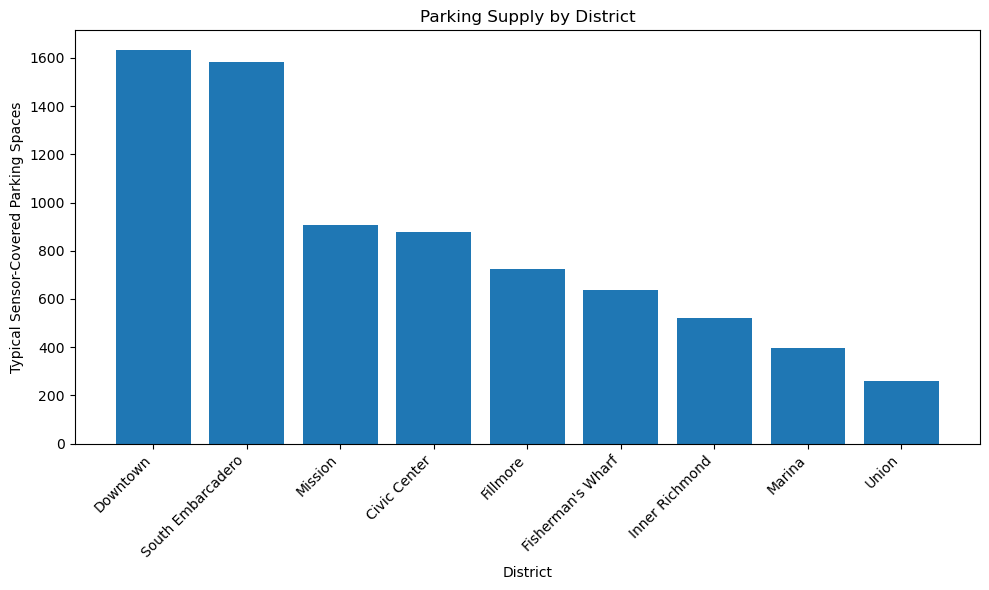

In [32]:
spaces_plot = (
    spaces_district
    .sort_values('mode_spaces', ascending=False)
    .reset_index()
)

plt.figure(figsize=(10, 6))

plt.bar(
    spaces_plot['PM_DISTRICT_NAME'],
    spaces_plot['mode_spaces']
)

plt.xlabel('District')
plt.ylabel('Typical Sensor-Covered Parking Spaces')
plt.title('Parking Supply by District')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.show()

In [33]:
ss.groupby('PM_DISTRICT_NAME')['BLOCK_ID'].nunique().sort_values(ascending=False)

PM_DISTRICT_NAME
Downtown             107
South Embarcadero     54
Civic Center          47
Fillmore              45
Fisherman's Wharf     43
Inner Richmond        31
Mission               31
Marina                27
Union                 16
Name: BLOCK_ID, dtype: int64

In [34]:
ss.groupby('PM_DISTRICT_NAME')['mode_spaces'].median().sort_values(ascending=False)

PM_DISTRICT_NAME
Mission              30.0
South Embarcadero    30.0
Civic Center         17.0
Fillmore             17.0
Inner Richmond       17.0
Fisherman's Wharf    15.0
Marina               14.0
Downtown             12.0
Union                11.5
Name: mode_spaces, dtype: float64

### Parking Availability

In [35]:
occupy = parking.copy()
occupy.head(3)

,BLOCK_ID,STREET_NAME,BLOCK_NUM,STREET_BLOCK,AREA_TYPE,PM_DISTRICT_NAME,RATE,START_TIME_DT,TOTAL_TIME,TOTAL_OCCUPIED_TIME,...,GMP_UNKNOWN_TIME,COMM_TIME,COMM_OCCUPIED_TIME,COMM_VACANT_TIME,COMM_UNKNOWN_TIME,CAL_MONTH_NAME,CAL_YEAR,CAL_DATE,DAY_TYPE,TIME_OF_DAY
0,41522,FILLMORE ST,22,FILLMORE ST 2200,Pilot,Fillmore,NaN,01-jul-2012 21:00:00,61200,35847,...,0,0,0,0,0,July,2012,2012-07-01,weekend,2100
1,41524,FILLMORE ST,24,FILLMORE ST 2400,Pilot,Fillmore,NaN,01-jul-2012 22:00:00,64800,27576,...,0,0,0,0,0,July,2012,2012-07-01,weekend,2200
2,50001,JACKSON ST,1,JACKSON ST 100,Pilot,Downtown,NaN,01-jul-2012 02:00:00,79200,39985,...,0,0,0,0,0,July,2012,2012-07-01,weekend,200


In [36]:
occupy['GMP_AVAILABILITY'] = (
    occupy['GMP_VACANT_TIME']
    /
    (
        occupy['GMP_OCCUPIED_TIME']
        + occupy['GMP_VACANT_TIME']
    )
)

In [37]:
(
    occupy['GMP_OCCUPIED_TIME']
    + occupy['GMP_VACANT_TIME']
    == 0
).sum()

np.int64(314156)

In [38]:
occupy['GMP_AVAILABILITY'].describe()

count    174140.000000
mean          0.341471
std           0.244455
min           0.000000
25%           0.146503
50%           0.303117
75%           0.500000
max           1.000000
Name: GMP_AVAILABILITY, dtype: float64

<Axes: >

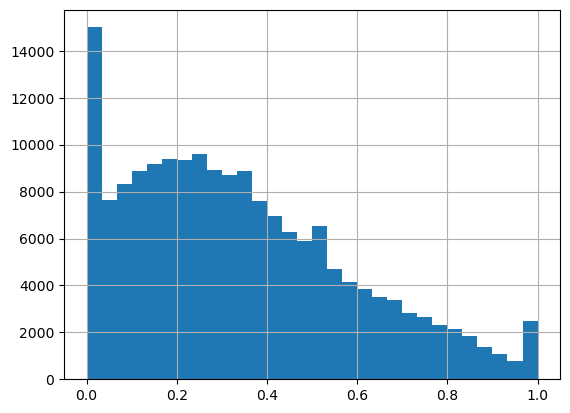

In [39]:
occupy['GMP_AVAILABILITY'].hist(bins=30)

In [40]:
time_occupy = occupy.groupby('TIME_OF_DAY')[['GMP_AVAILABILITY']].mean().reset_index()
time_occupy['TIME_OF_DAY'] = time_occupy['TIME_OF_DAY'] / 100
time_occupy['TIME_OF_DAY'] = time_occupy['TIME_OF_DAY'].astype(int)
time_occupy

,TIME_OF_DAY,GMP_AVAILABILITY
0,0,NaN
1,1,NaN
2,2,NaN
3,3,NaN
4,4,NaN
5,5,NaN
6,6,NaN
7,7,0.571819
8,8,0.504697
9,9,0.433616


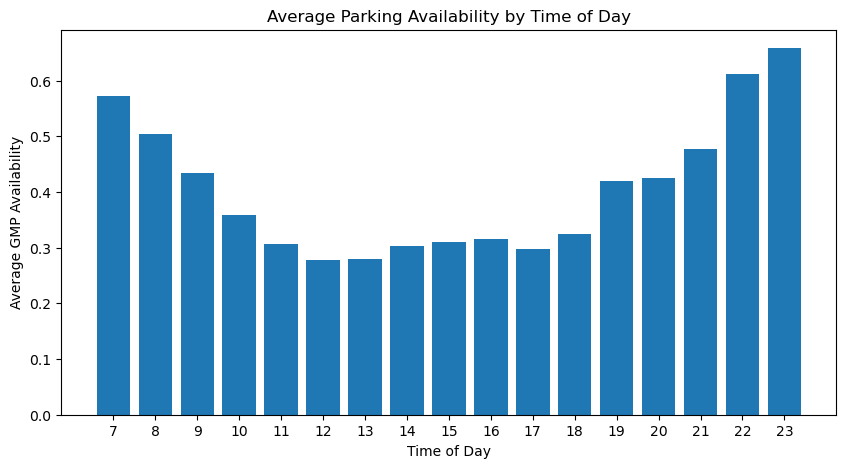

In [41]:
time_occupy_plot = time_occupy.dropna().copy()

time_occupy_plot['TIME_OF_DAY'] = (
    time_occupy_plot['TIME_OF_DAY'].astype(str)
)

plt.figure(figsize=(10, 5))

plt.bar(
    time_occupy_plot['TIME_OF_DAY'],
    time_occupy_plot['GMP_AVAILABILITY']
)

plt.xlabel('Time of Day')
plt.ylabel('Average GMP Availability')
plt.title('Average Parking Availability by Time of Day')

plt.show()

In [42]:
block_availability = occupy.groupby(
    ['BLOCK_ID', 'STREET_BLOCK', 'PM_DISTRICT_NAME']
)['GMP_AVAILABILITY'].agg(
    count='count',
    mean='mean',
    median='median',
    min='min',
    max='max',
    std='std'
).reset_index()

block_availability.head()

,BLOCK_ID,STREET_BLOCK,PM_DISTRICT_NAME,count,mean,median,min,max,std
0,902,California and Steiner Lot,Fillmore,650,0.302154,0.267954,0.000448,0.904592,0.200551
1,10202,02ND AVE 200,Inner Richmond,228,0.179440,0.048194,0.000000,1.000000,0.253171
2,10203,02ND AVE 300,Inner Richmond,380,0.412146,0.423040,0.000000,1.000000,0.215126
3,10302,03RD AVE 200,Inner Richmond,413,0.268318,0.201667,0.000000,1.000000,0.261078
4,10303,03RD AVE 300,Inner Richmond,433,0.213252,0.156349,0.000000,1.000000,0.214015


In [43]:
district_availability = occupy.groupby(
    'PM_DISTRICT_NAME'
)['GMP_AVAILABILITY'].agg(
    count='count',
    mean='mean',
    median='median',
    min='min',
    max='max',
    std='std'
).reset_index()

district_availability.head()

,PM_DISTRICT_NAME,count,mean,median,min,max,std
0,Civic Center,21342,0.414315,0.391486,0.0,1.0,0.249829
1,Downtown,34287,0.358484,0.315799,0.0,1.0,0.278905
2,Fillmore,20601,0.298897,0.278417,0.0,1.0,0.203784
3,Fisherman's Wharf,26316,0.322727,0.263082,0.0,1.0,0.267327
4,Inner Richmond,14469,0.278941,0.249038,0.0,1.0,0.196430


In [44]:
district_availability.sort_values('mean',ascending=False)

,PM_DISTRICT_NAME,count,mean,median,min,max,std
7,South Embarcadero,29167,0.425881,0.410042,0.0,1.0,0.240925
0,Civic Center,21342,0.414315,0.391486,0.0,1.0,0.249829
1,Downtown,34287,0.358484,0.315799,0.0,1.0,0.278905
3,Fisherman's Wharf,26316,0.322727,0.263082,0.0,1.0,0.267327
2,Fillmore,20601,0.298897,0.278417,0.0,1.0,0.203784
8,Union,6647,0.279602,0.269959,0.0,1.0,0.171648
4,Inner Richmond,14469,0.278941,0.249038,0.0,1.0,0.196430
6,Mission,8893,0.267396,0.237222,0.0,1.0,0.170069
5,Marina,12418,0.240417,0.217952,0.0,1.0,0.163460


In [45]:
district_availability.sort_values('mean',ascending=True)

,PM_DISTRICT_NAME,count,mean,median,min,max,std
5,Marina,12418,0.240417,0.217952,0.0,1.0,0.163460
6,Mission,8893,0.267396,0.237222,0.0,1.0,0.170069
4,Inner Richmond,14469,0.278941,0.249038,0.0,1.0,0.196430
8,Union,6647,0.279602,0.269959,0.0,1.0,0.171648
2,Fillmore,20601,0.298897,0.278417,0.0,1.0,0.203784
3,Fisherman's Wharf,26316,0.322727,0.263082,0.0,1.0,0.267327
1,Downtown,34287,0.358484,0.315799,0.0,1.0,0.278905
0,Civic Center,21342,0.414315,0.391486,0.0,1.0,0.249829
7,South Embarcadero,29167,0.425881,0.410042,0.0,1.0,0.240925


In [46]:
district_weighted = occupy.groupby(
    'PM_DISTRICT_NAME'
).agg(
    vacant_time=('GMP_VACANT_TIME', 'sum'),
    occupied_time=('GMP_OCCUPIED_TIME', 'sum')
).reset_index()

district_weighted['availability'] = (
    district_weighted['vacant_time']
    /
    (
        district_weighted['vacant_time']
        + district_weighted['occupied_time']
    )
)

district_weighted.head()

,PM_DISTRICT_NAME,vacant_time,occupied_time,availability
0,Civic Center,471176085,637559958,0.424967
1,Downtown,465825403,833041363,0.358640
2,Fillmore,312287406,708569371,0.305907
3,Fisherman's Wharf,355834646,711459045,0.333399
4,Inner Richmond,186854474,515179175,0.266162


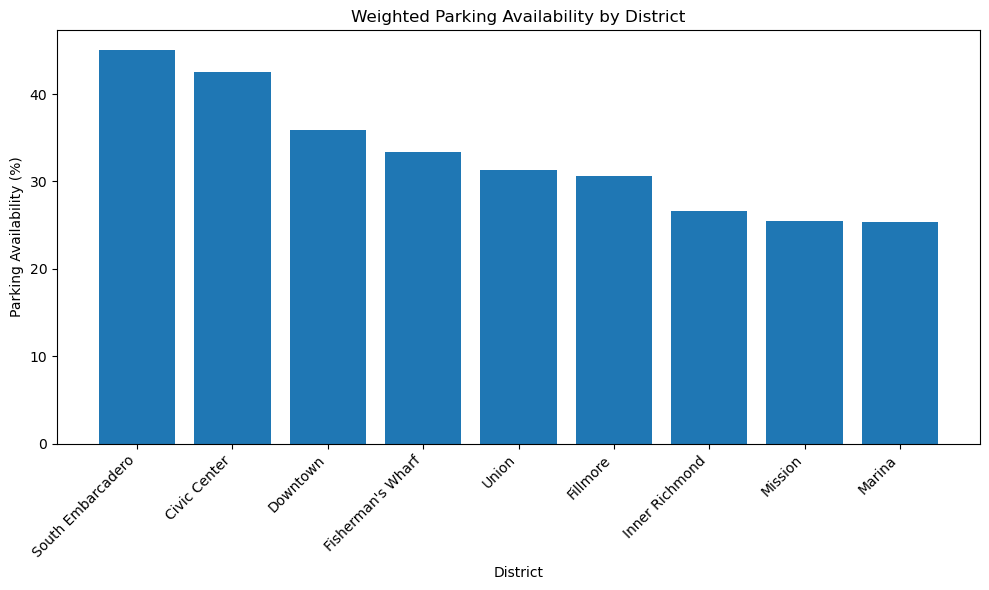

In [47]:
district_plot = district_weighted.sort_values(
    'availability',
    ascending=False
)

plt.figure(figsize=(10, 6))

plt.bar(
    district_plot['PM_DISTRICT_NAME'],
    district_plot['availability'] * 100
)

plt.xlabel('District')
plt.ylabel('Parking Availability (%)')
plt.title('Weighted Parking Availability by District')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.show()

### Pricing Analysis

In [48]:
pricing = occupy.copy()

In [49]:
print('Total observations:', pricing.shape[0])
print('Known rates:', pricing['RATE'].notna().sum())
print('Missing rates:', pricing['RATE'].isna().sum())

print(
    'Percent missing:',
    round(pricing['RATE'].isna().mean() * 100, 2)
)

Total observations: 488296
Known rates: 173022
Missing rates: 315274
Percent missing: 64.57


In [50]:
pd.crosstab(
    pricing['PM_DISTRICT_NAME'],
    pricing['AREA_TYPE']
)

AREA_TYPE,Control,Pilot
PM_DISTRICT_NAME,,
Civic Center,0,57229
Downtown,0,125345
Fillmore,0,59592
Fisherman's Wharf,0,53864
Inner Richmond,42965,0
Marina,0,36614
Mission,0,25815
South Embarcadero,0,67644
Union,19228,0


In [51]:
pilot_gmp = pricing[
    (pricing['AREA_TYPE'] == 'Pilot')
    & (pricing['GMP_TIME'] > 0)
].copy()

In [52]:
pilot_rate_coverage = pilot_gmp.groupby(
    'PM_DISTRICT_NAME'
).agg(
    total=('RATE', 'size'),
    known=('RATE', 'count'),
    missing=('RATE', lambda x: x.isna().sum()),
    pct_missing=('RATE', lambda x: x.isna().mean() * 100)
)

pilot_rate_coverage

,total,known,missing,pct_missing
PM_DISTRICT_NAME,,,,
Civic Center,21533,21533,0,0.000000
Downtown,35850,35850,0,0.000000
Fillmore,20673,20673,0,0.000000
Fisherman's Wharf,26953,26257,696,2.582273
Marina,12450,12450,0,0.000000
Mission,8893,8893,0,0.000000
South Embarcadero,29218,29218,0,0.000000


In [53]:
pricing_analysis = pilot_gmp[
    pilot_gmp['RATE'].notna()
].copy()

print('Pricing observations:', pricing_analysis.shape[0])
print('Blocks:', pricing_analysis['BLOCK_ID'].nunique())
print('Districts:', pricing_analysis['PM_DISTRICT_NAME'].nunique())

Pricing observations: 154874
Blocks: 351
Districts: 7


In [54]:
pricing_analysis['RATE'].describe()

count    154874.000000
mean          2.690187
std           1.342617
min           0.250000
25%           1.750000
50%           3.000000
75%           3.500000
max           7.000000
Name: RATE, dtype: float64

In [55]:
np.sort(pricing_analysis['RATE'].unique())

array([0.25, 0.5 , 0.75, 1.  , 1.25, 1.5 , 1.75, 2.  , 2.25, 2.5 , 2.75,
       3.  , 3.25, 3.5 , 3.75, 4.  , 4.25, 4.5 , 4.75, 5.  , 5.25, 5.5 ,
       5.75, 6.  , 7.  ])

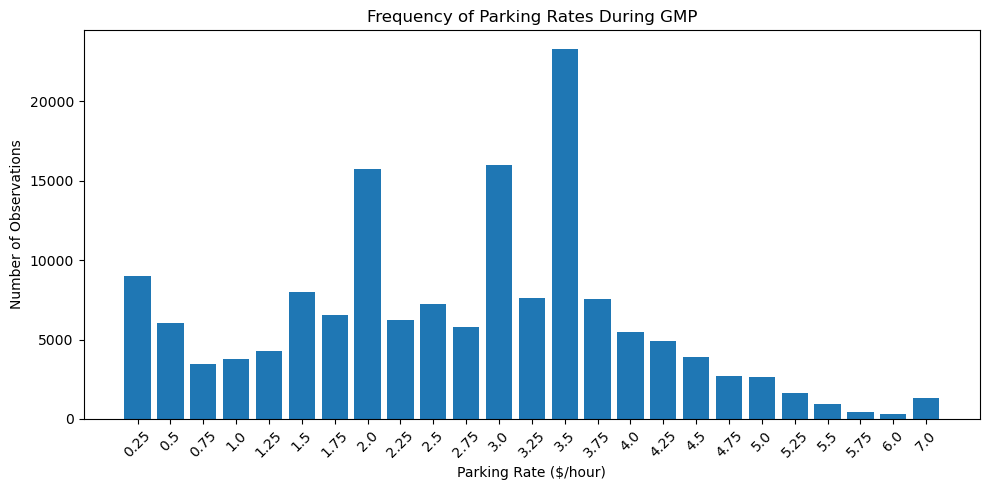

In [56]:
rate_counts = (
    pricing_analysis['RATE']
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(10, 5))

plt.bar(
    rate_counts.index.astype(str),
    rate_counts.values
)

plt.xlabel('Parking Rate ($/hour)')
plt.ylabel('Number of Observations')
plt.title('Frequency of Parking Rates During GMP')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [57]:
district_rates = pricing_analysis.groupby(
    'PM_DISTRICT_NAME'
)['RATE'].agg(
    count='count',
    mean='mean',
    median='median',
    min='min',
    max='max',
    num_rates='nunique'
).reset_index()

district_rates.sort_values(
    'median',
    ascending=False
)

,PM_DISTRICT_NAME,count,mean,median,min,max,num_rates
1,Downtown,35850,3.622162,3.50,0.25,6.0,24
0,Civic Center,21533,2.291715,2.50,0.25,5.5,22
3,Fisherman's Wharf,26257,2.401245,2.50,0.25,5.5,22
6,South Embarcadero,29218,2.538769,2.50,0.25,7.0,25
2,Fillmore,20673,2.329838,2.25,0.25,4.5,18
5,Mission,8893,2.449961,2.25,0.25,4.5,18
4,Marina,12450,2.430402,2.00,0.25,4.5,18


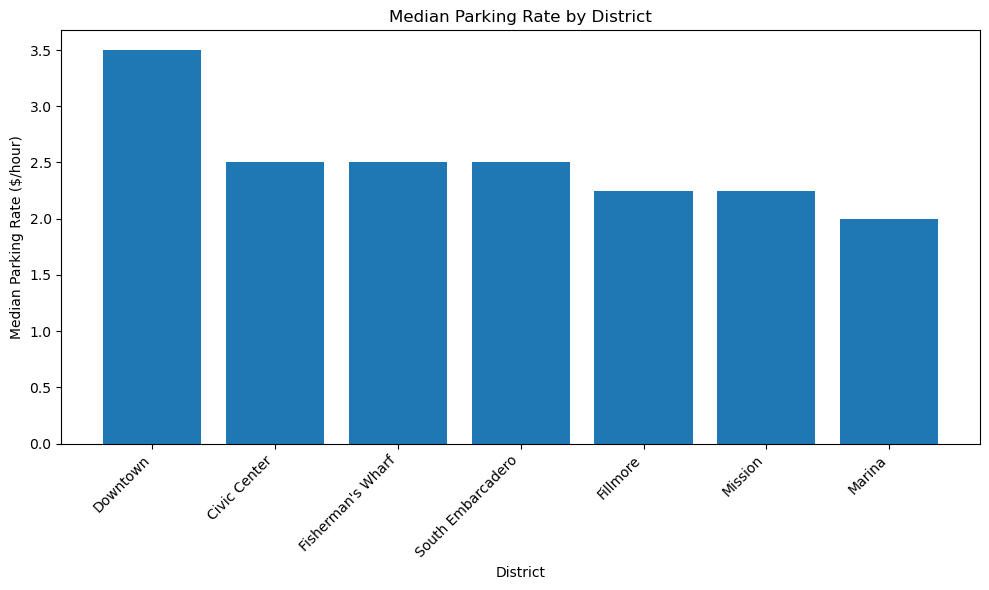

In [58]:
district_rate_plot = district_rates.sort_values(
    'median',
    ascending=False
)

plt.figure(figsize=(10, 6))

plt.bar(
    district_rate_plot['PM_DISTRICT_NAME'],
    district_rate_plot['median']
)

plt.xlabel('District')
plt.ylabel('Median Parking Rate ($/hour)')
plt.title('Median Parking Rate by District')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [59]:
block_rates = pricing_analysis.groupby(
    ['BLOCK_ID', 'STREET_BLOCK', 'PM_DISTRICT_NAME']
)['RATE'].agg(
    count='count',
    mean='mean',
    median='median',
    min='min',
    max='max',
    num_rates='nunique'
).reset_index()

block_rates['num_rates'].describe()

count    351.000000
mean       8.735043
std        5.532852
min        1.000000
25%        3.000000
50%        9.000000
75%       13.000000
max       22.000000
Name: num_rates, dtype: float64

In [60]:
print(
    'Blocks with one recorded rate:',
    (block_rates['num_rates'] == 1).sum()
)

print(
    'Blocks with multiple recorded rates:',
    (block_rates['num_rates'] > 1).sum()
)

Blocks with one recorded rate: 75
Blocks with multiple recorded rates: 276


In [61]:
block_rates.sort_values(
    'num_rates',
    ascending=False
).head(10)

,BLOCK_ID,STREET_BLOCK,PM_DISTRICT_NAME,count,mean,median,min,max,num_rates
43,32606,BEACH ST 600,Fisherman's Wharf,812,2.700739,3.00,0.25,5.50,22
252,61231,POLK ST 3100,Fisherman's Wharf,930,2.163172,2.50,0.25,5.25,21
200,56225,MASON ST 2500,Fisherman's Wharf,642,2.356698,3.00,0.25,5.50,21
187,54627,LEAVENWORTH ST 2700,Fisherman's Wharf,811,2.272811,2.50,0.25,5.00,20
251,61203,POLK ST 300,Civic Center,594,3.844276,4.00,0.25,5.50,20
7,20203,02ND ST 300,South Embarcadero,513,3.558967,3.50,0.75,5.50,20
199,56224,MASON ST 2400,Fisherman's Wharf,644,1.373059,1.50,0.25,5.25,20
165,50002,JACKSON ST 200,Downtown,365,4.358219,4.50,1.00,5.50,19
166,50003,JACKSON ST 300,Downtown,434,3.510945,3.50,0.50,5.25,19
321,72003,WASHINGTON ST 300,Downtown,408,4.050858,4.25,0.25,5.50,18


In [62]:
hourly_rates = pricing_analysis.groupby(
    'TIME_OF_DAY'
)['RATE'].agg(
    count='count',
    mean='mean',
    median='median'
).reset_index()

hourly_rates['HOUR'] = (
    hourly_rates['TIME_OF_DAY'] // 100
)

hourly_rates

,TIME_OF_DAY,count,mean,median,HOUR
0,700,6697,2.544348,3.00,7
1,800,6742,2.540826,3.00,8
2,900,14149,2.313043,2.25,9
3,1000,14258,2.329043,2.25,10
4,1100,14334,2.321735,2.25,11
5,1200,15046,3.074787,3.25,12
6,1300,15168,3.076460,3.25,13
7,1400,15169,3.074494,3.25,14
8,1500,14587,2.941249,3.00,15
9,1600,14496,2.956850,3.00,16


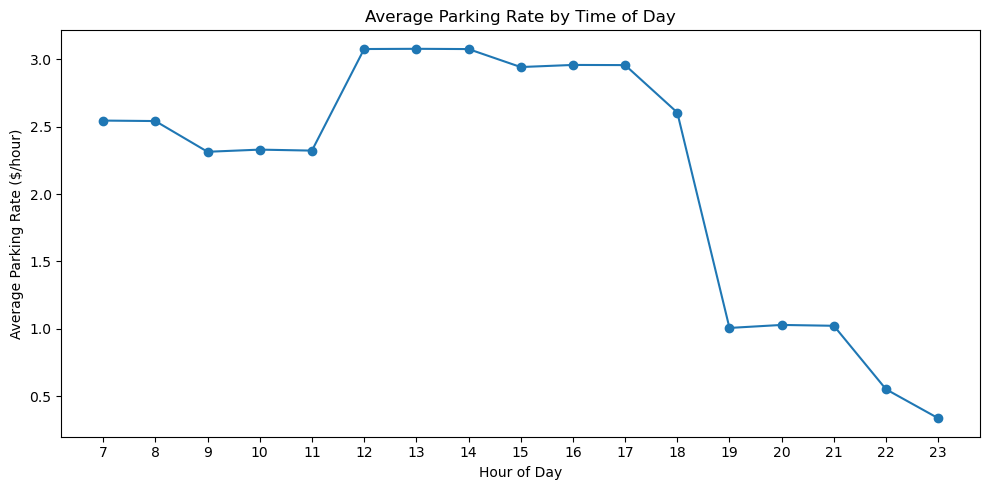

In [63]:
plt.figure(figsize=(10, 5))

plt.plot(
    hourly_rates['HOUR'],
    hourly_rates['mean'],
    marker='o'
)

plt.xlabel('Hour of Day')
plt.ylabel('Average Parking Rate ($/hour)')
plt.title('Average Parking Rate by Time of Day')

plt.xticks(hourly_rates['HOUR'])

plt.tight_layout()
plt.show()

In [64]:
day_rates = pricing_analysis.groupby(
    'DAY_TYPE'
)['RATE'].agg(
    count='count',
    mean='mean',
    median='median',
    min='min',
    max='max'
)

day_rates

,count,mean,median,min,max
DAY_TYPE,,,,,
weekday,125821,2.689126,3.0,0.25,7.0
weekend,29053,2.694782,3.0,0.25,7.0


In [65]:
pricing_analysis['YEAR_MONTH'] = (
    pricing_analysis['CAL_DATE'].dt.to_period('M')
)

monthly_rates = pricing_analysis.groupby(
    'YEAR_MONTH'
)['RATE'].mean()

monthly_rates.head()

YEAR_MONTH
2011-04    2.425926
2011-05    2.657852
2011-06    2.625000
2011-07    2.544349
2011-08    3.046635
Freq: M, Name: RATE, dtype: float64

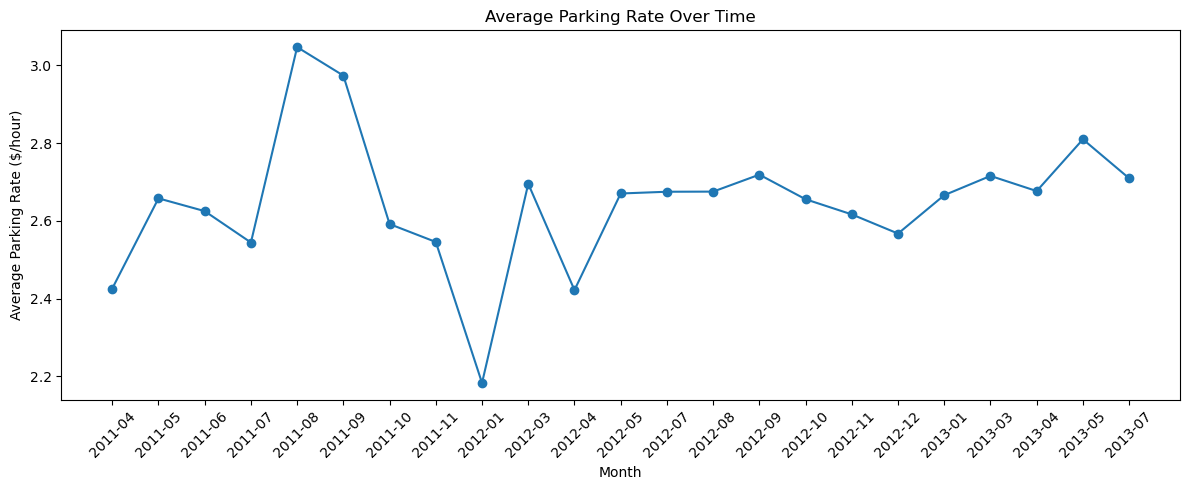

In [66]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_rates.index.astype(str),
    monthly_rates.values,
    marker='o'
)

plt.xlabel('Month')
plt.ylabel('Average Parking Rate ($/hour)')
plt.title('Average Parking Rate Over Time')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [67]:
pricing_availability = pricing_analysis[
    pricing_analysis['GMP_AVAILABILITY'].notna()
].copy()

print(pricing_availability.shape)

(152328, 35)


In [68]:
rate_weighted = pricing_availability.groupby(
    'RATE'
).agg(
    observations=('RATE', 'size'),
    vacant_time=('GMP_VACANT_TIME', 'sum'),
    occupied_time=('GMP_OCCUPIED_TIME', 'sum')
).reset_index()

rate_weighted['availability'] = (
    rate_weighted['vacant_time']
    /
    (
        rate_weighted['vacant_time']
        + rate_weighted['occupied_time']
    )
)

rate_weighted

,RATE,observations,vacant_time,occupied_time,availability
0,0.25,8948,330955611,294425971,0.529206
1,0.50,5782,168311049,168131545,0.500267
2,0.75,3336,87473211,108989548,0.445241
3,1.00,3728,99356312,118342075,0.456394
4,1.25,4262,117720157,137613463,0.461044
5,1.50,7939,344109555,341113005,0.502187
6,1.75,6494,155169274,221171580,0.412310
7,2.00,15670,335534573,564928413,0.372625
8,2.25,6157,110966225,234447483,0.321256
9,2.50,7066,143389227,276135399,0.341790


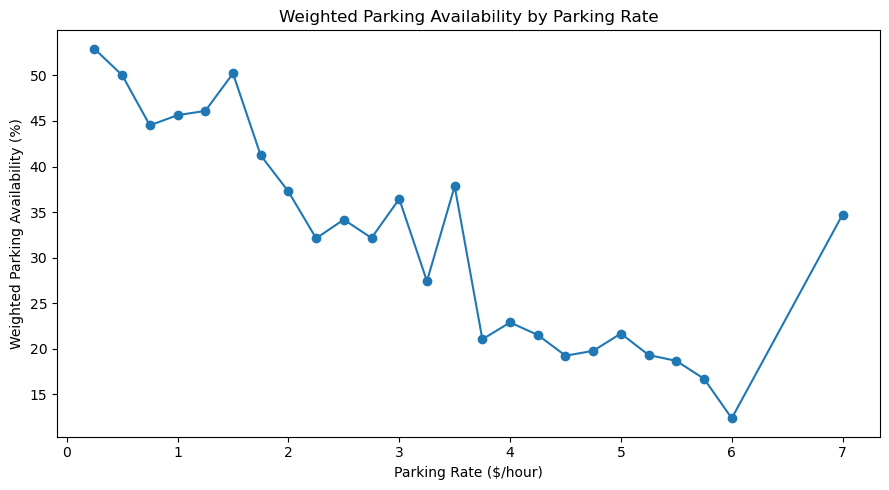

In [69]:
plt.figure(figsize=(9, 5))

plt.plot(
    rate_weighted['RATE'],
    rate_weighted['availability'] * 100,
    marker='o'
)

plt.xlabel('Parking Rate ($/hour)')
plt.ylabel('Weighted Parking Availability (%)')
plt.title('Weighted Parking Availability by Parking Rate')

plt.tight_layout()
plt.show()